In [187]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('C:/Users/kosti/Desktop/DATASCI 281/Final Project/images'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8ddaa5a5caa5caa8.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8ddaac1bd6c8cd0a.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8ddd5ec1c0de38c4.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8def3f60308ab41b.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8def4d91382175c3.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8df452e2e38c0b6e.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8dfae9d78cc32089.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8e3dbccdfe08c850.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8e68163c62dc57d5.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8e6a823cce9ff40c.jpg
C:/Users/kosti/Desktop/DATASCI 281/Final Project/images\Test\Healthy\8e77857194a59a87.jpg
C:/Users/k

In [188]:
import os

# Analyze the folder structure
dataset_dir = "C:/Users/kosti/Desktop/DATASCI 281/Final Project/images"
for folder in os.listdir(dataset_dir):
    print(f"Folder: {folder}")
    subfolder_path = os.path.join(dataset_dir, folder)
    if os.path.isdir(subfolder_path):
        print(f"Subfolders in {folder}: {os.listdir(subfolder_path)}")

Folder: Test
Subfolders in Test: ['Healthy', 'Powdery', 'Rust']
Folder: Train
Subfolders in Train: ['Healthy', 'Powdery', 'Rust']
Folder: Validation
Subfolders in Validation: ['Healthy', 'Powdery', 'Rust']


Processing class: Healthy


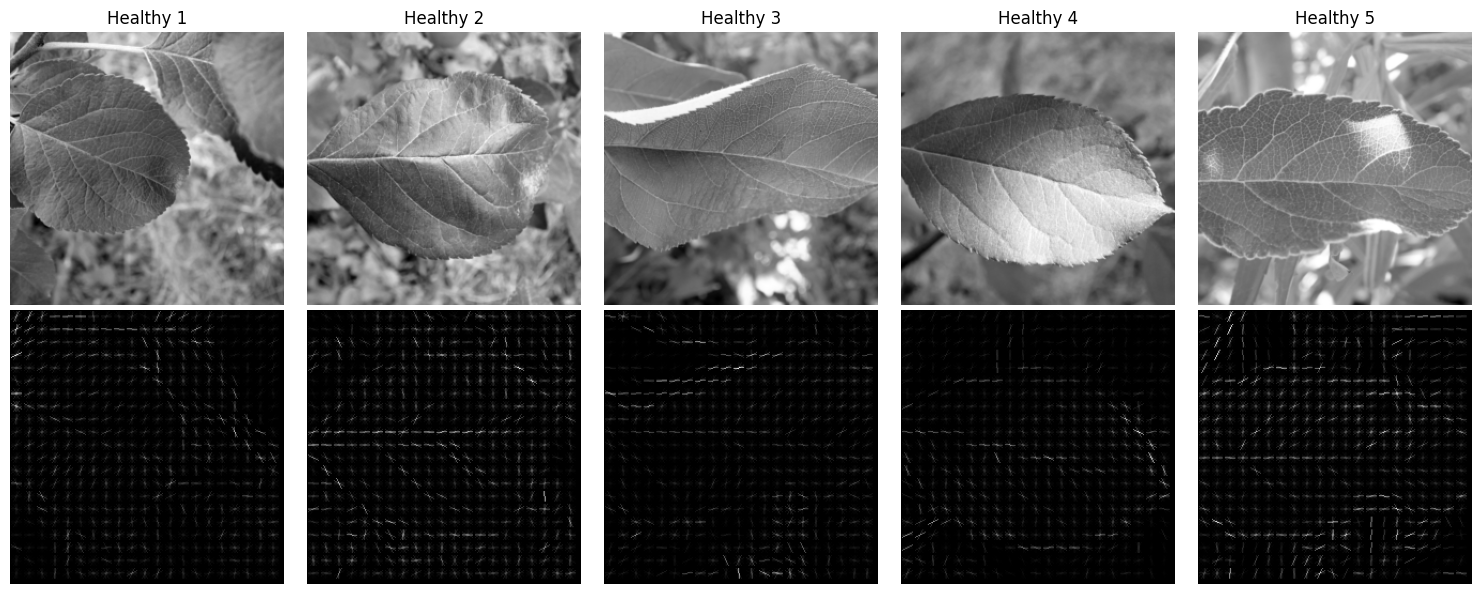

Processing class: Powdery


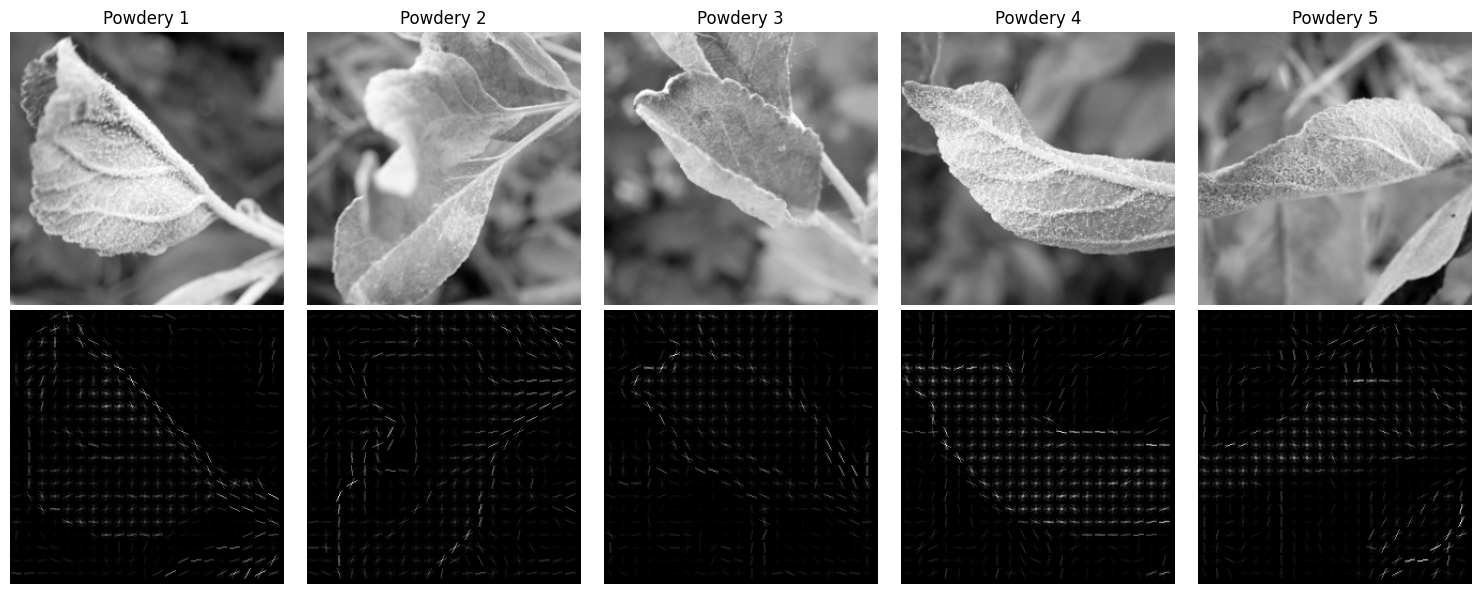

Processing class: Rust


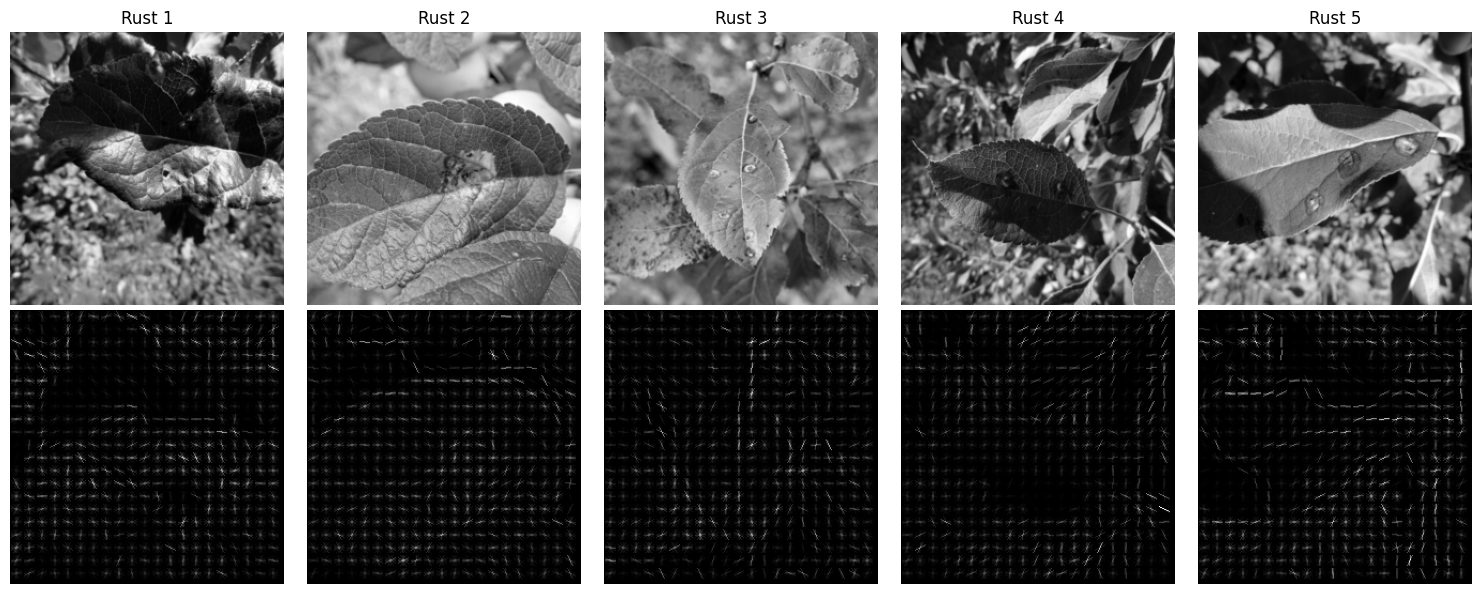

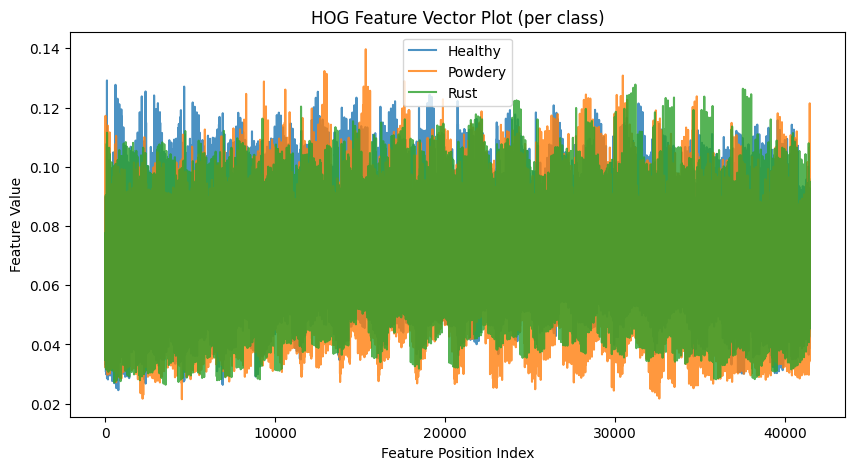

Processed 60 images across 3 classes.
Validation data: 60 samples, 3 classes


In [189]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.transform import rescale
from skimage.color import rgb2gray
from PIL import Image

# read image, convert to grayscale, scale to [0,1]
def read_image(in_path):
    img = np.array(Image.open(in_path))
    if np.max(img) > 1:
        img = img.astype(np.float32) / 255.0
    if len(img.shape) > 2:
        img = rgb2gray(img)
    return img

# rescale short side to standard, crop center
def rescale_image(img, standard=256):
    x, y = img.shape
    scale_factor = standard / min(x, y)
    img_rescaled = rescale(img, scale_factor, anti_aliasing=True)
    x_new, y_new = img_rescaled.shape
    start_h = (x_new - standard) // 2
    start_w = (y_new - standard) // 2
    cropped_img = img_rescaled[start_h:start_h + standard, start_w:start_w + standard]
    return cropped_img

# load images from folder and extract HOG features
def load_hog_data(folder_path, visualize=True, max_visualize=5):
    features, labels = [], []
    class_features = {}  # store features per class for plotting

    for label in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, label)
        if not os.path.isdir(class_dir):
            continue
        print(f"Processing class: {label}")
        class_features[label] = []

        visualize_count = 0  # track visualized images per class
        imgs_to_show, hots_to_show = [], []

        for image_file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_file)
            img = read_image(image_path)
            img_resized = rescale_image(img)

            # visualize only first max_visualize images per class
            vis = visualize and visualize_count < max_visualize
            f, h = hog(
                img_resized,
                orientations=8,
                pixels_per_cell=(12,12),
                cells_per_block=(4,4),
                visualize=True,
                feature_vector=True
            )

            if vis:
                imgs_to_show.append(img_resized)
                hots_to_show.append(h)
                visualize_count += 1

            features.append(f)
            labels.append(label)
            class_features[label].append(f)

        # plot images and HOGs for this class
        if visualize_count > 0:
            n = len(imgs_to_show)
            fig, axs = plt.subplots(2, n, figsize=(3*n,6))
            for i in range(n):
                axs[0,i].imshow(imgs_to_show[i], cmap='gray')
                axs[0,i].axis('off')
                axs[0,i].set_title(f'{label} {i+1}')
                axs[1,i].imshow(hots_to_show[i], cmap='gray')
                axs[1,i].axis('off')
            plt.tight_layout()
            plt.show()

    # --- Plot averaged HOG per class ---
    plt.figure(figsize=(10, 5))
    for label, feats in class_features.items():
        feats_array = np.array(feats)
        mean_feat = feats_array.mean(axis=0)
        plt.plot(mean_feat, alpha=0.8, label=label)

    plt.title("HOG Feature Vector Plot (per class)")
    plt.xlabel("Feature Position Index")
    plt.ylabel("Feature Value")
    plt.legend()
    plt.show()

    print(f"Processed {len(features)} images across {len(set(labels))} classes.")
    return np.array(features), np.array(labels)


# Example usage
valid_dir = "C:/Users/kosti/Desktop/DATASCI 281/Final Project/images/Validation"
valid_features, valid_labels = load_hog_data(valid_dir, visualize=True, max_visualize=5)

print(f"Validation data: {valid_features.shape[0]} samples, {len(set(valid_labels))} classes")
